### 基础神经网络分类模型

本章节以MNIST手写数字数据集为例，教大家构建基础的神经网络分类模型。MNIST是经典数据集，含6万训练样本、1万测试样本，每个样本是28x28像素的手写数字图像，目标是将图像分类为0 - 9这10个数字。

#### 模型概述
基础神经网络分类模型包含输入层、隐藏层和输出层。输入层接收图像数据，隐藏层提取和转换特征，输出层给出分类结果。

#### 实现步骤
1. **数据加载与预处理**：加载MNIST训练集和测试集，并归一化处理。
2. **模型构建**：定义网络结构，包括层数、神经元数量和激活函数。
3. **目标定义**：选择损失函数、优化器和评估指标。
4. **模型训练**：用训练数据训练模型，监控损失和准确率。
5. **模型评估**：用测试数据评估模型性能。
6. **模型预测**：用训练好的模型对新数据预测。

下面我们将逐步实现这些步骤，构建一个简单有效的神经网络分类模型。


In [1]:
# 生成一个简单的三层神经网络，要求输入是3维，两个隐层分别为40个神经元，最后输出3个类别
import torch
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(3, 40) # 输入层到第一个隐层的全连接层，输入维度为3，输出维度为40
        self.fc2 = nn.Linear(40, 40) # 第一个隐层到第二个隐层的全连接层，输入维度为40，输出维度为40
        self.fc3 = nn.Linear(40, 3) # 第二个隐层到输出层的全连接层，输入维度为40，输出维度为3（对应3个类别）
        self.relu = nn.ReLU() # 定义激活函数为ReLU       

    def forward(self, x): # 前向传播函数，定义了数据如何通过网络流动
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()
print(net)

sample_x = torch.randn(2, 3)
sample_logits = net(sample_x)
print('输出张量形状:', sample_logits.shape)

for name, param in net.named_parameters():
    print(name, param.shape)

Net(
  (fc1): Linear(in_features=3, out_features=40, bias=True)
  (fc2): Linear(in_features=40, out_features=40, bias=True)
  (fc3): Linear(in_features=40, out_features=3, bias=True)
  (relu): ReLU()
)
输出张量形状: torch.Size([2, 3])
fc1.weight torch.Size([40, 3])
fc1.bias torch.Size([40])
fc2.weight torch.Size([40, 40])
fc2.bias torch.Size([40])
fc3.weight torch.Size([3, 40])
fc3.bias torch.Size([3])


### 01 加载MNIST数据集

#### 关键知识点探究
- **`transforms.Compose` 和 `normalize` 的作用**：它们的作用是什么呢？
- **`squeeze()` 函数的作用**：这个函数有什么作用呢？


正在加载MNIST数据集...
第 10085 个样本的标签: 1
样本张量形状: torch.Size([1, 28, 28])


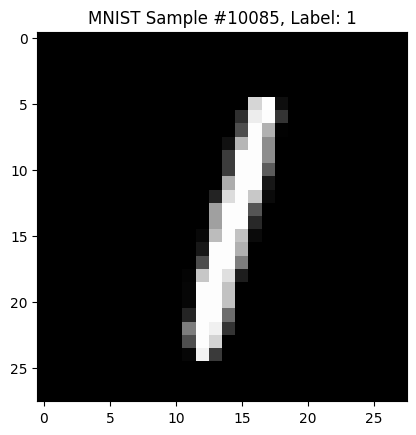

In [2]:
# 读取当前目录中的 MNIST 数据集
import torch
import torch.nn as nn
import torch.optim as optim # optim是PyTorch中用于优化模型参数的模块，提供了各种优化算法，如SGD、Adam等。
from torch.utils.data import DataLoader # DataLoader是PyTorch中用于加载数据的模块，可以方便地批量加载数据并进行数据增强等操作。
from torchvision import datasets, transforms # torchvision是PyTorch中用于处理图像数据的模块，提供了各种图像处理工具和数据集。transforms是torchvision中的一个子模块，提供了各种图像变换操作，如随机裁剪、随机水平翻转、归一化等。
import matplotlib.pyplot as plt  

# 数据预处理：先转为张量，再按 MNIST 的均值和标准差做标准化
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST数据集的均值和标准差，通过先验分析获得，用于将图像数据归一化到0-1之间
])

# torchvision 会在当前目录下自动管理 MNIST 数据文件
print("正在加载MNIST数据集...")
train_dataset = datasets.MNIST(root='.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='.', train=False, download=True, transform=transform)

# 选取一个样本进行展示
sample_index = 10085
image, label = train_dataset[sample_index]
display_image = image.squeeze() * 0.3081 + 0.1307 # 将图像数据从归一化范围（0-1）恢复到原始范围（0-255）

print(f"第 {sample_index} 个样本的标签: {label}")
print('样本张量形状:', image.shape)
plt.imshow(display_image, cmap='gray')
plt.title(f"MNIST Sample #{sample_index}, Label: {label}")
plt.show()

In [3]:
# 创建数据加载器
# 以下代码创建数据加载器，`DataLoader` 是 PyTorch 中用于批量加载数据的工具
# `train_loader` 用于加载训练数据，`batch_size=64` 表示每次加载 64 个样本，`shuffle=True` 表示每个 epoch 开始前打乱数据顺序
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# `test_loader` 用于加载测试数据，`batch_size=64` 表示每次加载 64 个样本，`shuffle=False` 表示不打乱数据顺序
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")


训练集大小: 60000
测试集大小: 10000


### 02 模型定义与损失函数
- 定义一个简单的神经网络模型，包含三层全连接层，激活函数为ReLU
- 模型的输入层为28x28的图像，输出层为10个类别
- 损失函数为交叉熵损失函数


In [4]:
# ?????????
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.flatten = nn.Flatten()  # ?28x28?????784?????????????????????????????????
        self.fc1 = nn.Linear(28*28, 128) # ????????????????????28*28=784??????128
        self.fc2 = nn.Linear(128, 64) # ??????????????????????128??????64
        self.fc3 = nn.Linear(64, 10) # ???????10?????? logits
        self.relu = nn.ReLU() # ReLU???????????????????????????
        self.dropout = nn.Dropout(p=0.3) # Dropout????????????????????, p?????
        self.loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss ?????? softmax??????????? softmax
        self.optimizer = optim.Adam(self.parameters(), lr=0.001) # Adam????????????lr????
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # ????????GPU???????GPU?????CPU
        
    # ????????????????????
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x
# ????
model = SimpleNet()
x = torch.randn(1, 1, 28, 28) # ??????????????(1, 1, 28, 28)?????????1???????????????28x28???
output = model(x)
print(output.shape)


torch.Size([1, 10])


<details>
<summary>模型结构定义参考</summary>

```python
    def forward(self, x):
        x = self.flatten(x) # 展平输入张量
        x = self.relu(self.fc1(x)) # 第一个隐层，并应用ReLU激活函数
        x = self.dropout(x) # Dropout层，随机失活部分神经元
        x = self.relu(self.fc2(x)) # 第二个隐层，并应用ReLU激活函数
        x = self.dropout(x) # Dropout层，随机失活部分神经元
        x = self.fc3(x) # 返回 logits，后续可直接用于损失计算或 argmax 预测
        return x
```
</details>

### 💡为什么前向不需要手动加 Softmax

这一节的模型最后一层输出的是 logits，也就是每个类别对应的原始分数。之所以不在 `forward()` 里手动加 softmax，主要有两个原因：

1. `nn.CrossEntropyLoss()` 在内部已经完成了 `log_softmax` 和负对数似然计算，因此训练时如果再手动加一次 softmax，反而会让数值稳定性变差。
2. 在预测类别时，我们只关心哪一个类别分数最大。由于 softmax 不会改变最大值所在的位置，所以 `outputs.argmax(dim=1)` 和 `softmax(outputs).argmax(dim=1)` 的分类结果相同。

只有在你想把结果展示成“概率分布”时，才需要在推理阶段额外写 `torch.softmax(outputs, dim=1)`。如果当前任务只是算损失或取预测类别，就不需要手动加。

### 训练模型及评估
- 训练模型5个epoch，每个epoch打印一次损失值和准确率
- 评估模型在测试集上的准确率

Epoch [1/5] - Train Loss: 0.3942, Train Acc: 88.21%, Test Loss: 0.1563, Test Acc: 95.22%
Epoch [2/5] - Train Loss: 0.2018, Train Acc: 94.13%, Test Loss: 0.1138, Test Acc: 96.50%
Epoch [3/5] - Train Loss: 0.1634, Train Acc: 95.17%, Test Loss: 0.1017, Test Acc: 96.94%
Epoch [4/5] - Train Loss: 0.1453, Train Acc: 95.74%, Test Loss: 0.0922, Test Acc: 97.08%
Epoch [5/5] - Train Loss: 0.1295, Train Acc: 96.16%, Test Loss: 0.0799, Test Acc: 97.47%
???????? mnist_model.pth


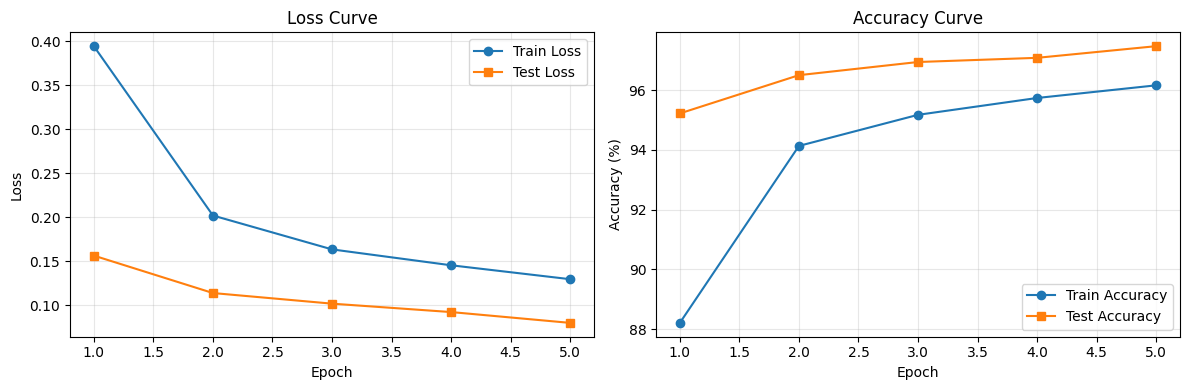

????????: 97.47%


In [5]:
# ????
# ?????????????????

num_epochs = 5
device = model.device
model = model.to(device)
criterion = model.loss_fn
optimizer = model.optimizer

train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = epoch_loss / total
    train_acc = 100 * correct / total
    train_loss_history.append(avg_loss)
    train_acc_history.append(train_acc)

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            predicted = outputs.argmax(dim=1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    avg_test_loss = test_loss / test_total
    test_acc = 100 * test_correct / test_total
    test_loss_history.append(avg_test_loss)
    test_acc_history.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Loss: {avg_test_loss:.4f}, Test Acc: {test_acc:.2f}%")

torch.save(model.state_dict(), 'mnist_model.pth')
print('???????? mnist_model.pth')

epochs = range(1, num_epochs + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_history, marker='o', label='Train Loss')
plt.plot(epochs, test_loss_history, marker='s', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_history, marker='o', label='Train Accuracy')
plt.plot(epochs, test_acc_history, marker='s', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curve')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"????????: {test_acc_history[-1]:.2f}%")


<details>
<summary>参考代码</summary>

```python
# 训练模型并保存参数，在测试集上评估

# 实验设置
num_epochs = 5
device = model.device
model = model.to(device)
criterion = model.loss_fn
optimizer = model.optimizer

# 训练模型
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1) # argmax函数自带softmax功能，返回最大值索引
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = epoch_loss / total
    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%")

torch.save(model.state_dict(), 'mnist_model.pth')
print("模型参数已保存到 mnist_model.pth")

# 评估模型
model.eval() # 设置模型为评估模式
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"测试集准确率: {test_acc:.2f}%")
```

</details>

### 测试testpic中的5张照片，输出模型的预测结果

???????: mnist_model.pth
1_1.png: ???? = [2.88898008e-07 9.95888412e-01 8.67193958e-05 9.35372082e-05
 4.08227897e-05 1.65366680e-06 3.14519241e-07 3.76115926e-03
 1.13610644e-04 1.35139335e-05]????? = 1????? = 1
1_2.png: ???? = [2.4367915e-03 2.4329333e-04 6.9408431e-03 2.0191143e-01 6.0868410e-07
 7.6822966e-01 3.6292628e-04 2.3951843e-06 1.9852757e-02 1.9254650e-05]????? = 5????? = 1
1_3.png: ???? = [7.0144864e-07 9.9814796e-01 1.3692700e-04 1.1453768e-04 1.8645331e-04
 1.7308392e-05 3.5176392e-05 4.3505992e-05 1.2990900e-03 1.8178021e-05]????? = 1????? = 1
2_1.png: ???? = [2.2305329e-09 1.1471337e-05 9.9979109e-01 1.7627201e-04 3.3800379e-11
 2.1493662e-09 1.6828589e-10 2.0721080e-05 4.6286263e-07 3.3348723e-11]????? = 2????? = 2
2_2.png: ???? = [6.3370362e-06 1.2413687e-04 8.5676557e-01 4.4735072e-05 4.7837284e-06
 9.8762603e-06 1.4299308e-01 1.0845020e-08 5.1520648e-05 2.6693850e-10]????? = 2????? = 2
testpic ????: 80.00%


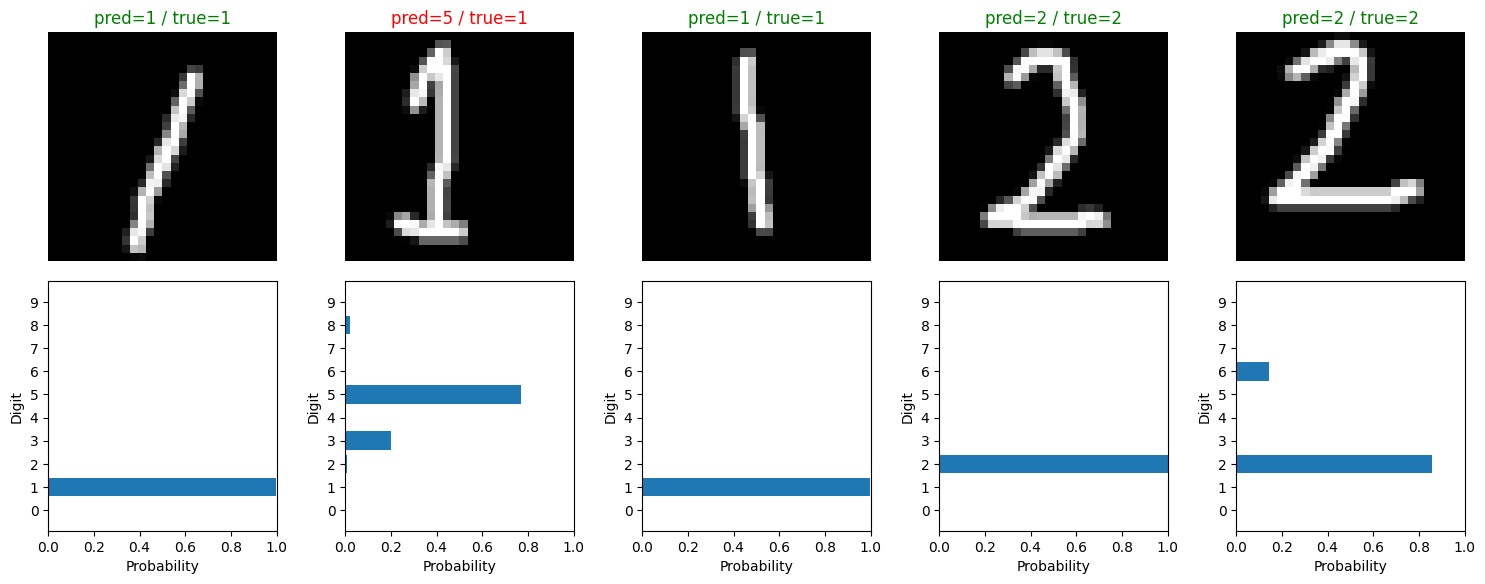

In [6]:
# ??????????? testpic ?? 5 ???????????????????????
from PIL import Image
import os
import torch
import matplotlib.pyplot as plt

test_dir = './testpic'
image_names = sorted([name for name in os.listdir(test_dir) if name.lower().endswith('.png')])
assert image_names, 'testpic ???????????? PNG ???'

checkpoint_path = 'mnist_model.pth'
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=model.device))
    model = model.to(model.device)
    print(f'???????: {checkpoint_path}')
else:
    print('????????????????????????????')

test_tensors = []
test_labels = []
raw_images = []

for filename in image_names:
    image_path = os.path.join(test_dir, filename)
    image = Image.open(image_path).convert('L').resize((28, 28))
    raw_images.append(image.copy())
    test_tensors.append(transform(image))
    test_labels.append(int(filename.split('_')[0]))

test_images = torch.stack(test_tensors).to(next(model.parameters()).device)
model.eval()
with torch.no_grad():
    outputs = model(test_images)
    predicted = outputs.argmax(dim=1)

for index, filename in enumerate(image_names):
    probs = torch.softmax(outputs[index], dim=0).detach().cpu().numpy()
    print(f"{filename}: ???? = {probs}????? = {predicted[index].item()}????? = {test_labels[index]}")

correct = (predicted == torch.tensor(test_labels, device=predicted.device)).sum().item()
accuracy = 100 * correct / len(test_labels)
print(f"testpic ????: {accuracy:.2f}%")

fig, axes = plt.subplots(2, len(raw_images), figsize=(3 * len(raw_images), 6))
if len(raw_images) == 1:
    axes = axes.reshape(-1, 1)

for index in range(len(raw_images)):
    axes[0, index].imshow(raw_images[index], cmap='gray')
    pred = predicted[index].item()
    true_label = test_labels[index]
    title_color = 'green' if pred == true_label else 'red'
    axes[0, index].set_title(f"pred={pred} / true={true_label}", color=title_color)
    axes[0, index].axis('off')

    probs = torch.softmax(outputs[index], dim=0).detach().cpu().numpy()
    axes[1, index].barh(range(10), probs)
    axes[1, index].set_yticks(range(10))
    axes[1, index].set_xlim(0, 1)
    axes[1, index].set_ylabel('Digit')
    axes[1, index].set_xlabel('Probability')

plt.tight_layout()
plt.show()


### 结果分析与误判说明

从当前结果可以看到，testpic 中有一张图片被误判了。这并不表示代码有问题，而是说明模型对“课堂外样本”的泛化能力还有限。

可能的原因包括：

1. testpic 中的手写风格与 MNIST 训练集差异较大，例如笔画粗细、倾斜角度、留白位置不同。
2. 图片虽然已经缩放到 28×28，但字符在画面中的位置、大小和对比度可能与训练样本不一致。
3. 当前模型是一个简单的全连接网络，对局部形状变化的鲁棒性不如卷积神经网络。

如果想进一步提高这部分的效果，可以尝试：

1. 在预测前增加二值化、居中、去噪等预处理。
2. 增加训练轮数，或适当调整网络规模与 dropout 参数。
3. 将模型替换为 CNN，再比较两类模型在 testpic 上的表现差异。

<details>
<summary>参考代码</summary>

```python
from PIL import Image
import os
import torch
import matplotlib.pyplot as plt

test_dir = './testpic'
image_names = sorted([name for name in os.listdir(test_dir) if name.lower().endswith('.png')])
assert image_names, 'testpic 文件夹中没有可用于测试的 PNG 图片。'

# 如果已经存在训练好的模型参数，则优先加载，避免单独重跑模型定义单元后参数被重置
checkpoint_path = 'mnist_model.pth'
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=model.device))
    model = model.to(model.device)
    print(f'已加载模型参数: {checkpoint_path}')
else:
    print('未找到已保存的模型参数，将使用当前内存中的模型进行预测。')

test_tensors = []
test_labels = []
raw_images = []

# 准备测试数据：读取 testpic 文件夹中的图片，转换为模型输入格式，并提取真实标签
for filename in image_names:
    image_path = os.path.join(test_dir, filename)
    image = Image.open(image_path).convert('L').resize((28, 28))
    raw_images.append(image.copy())
    test_tensors.append(transform(image))
    test_labels.append(int(filename.split('_')[0]))

# 模型预测
test_images = torch.stack(test_tensors).to(next(model.parameters()).device)
model.eval()
with torch.no_grad():
    outputs = model(test_images)  # outputs 是 logits，这里直接取 argmax 即可，无需手动加 softmax
    predicted = outputs.argmax(dim=1)

for index, filename in enumerate(image_names):
    print(f"{filename}: 输出概率 = {torch.softmax(outputs[index], dim=0).detach().cpu().numpy()}，预测标签 = {predicted[index].item()}，真实标签 = {test_labels[index]}")
   
correct = (predicted == torch.tensor(test_labels, device=predicted.device)).sum().item()
accuracy = 100 * correct / len(test_labels)
print(f"testpic 测试精度: {accuracy:.2f}%")

fig, axes = plt.subplots(2, len(raw_images), figsize=(3 * len(raw_images), 6))
if len(raw_images) == 1:
    axes = axes.reshape(-1, 1)

for index in range(len(raw_images)):
    # 显示图片
    axes[0, index].imshow(raw_images[index], cmap='gray')
    pred = predicted[index].item()
    true_label = test_labels[index]
    title_color = 'green' if pred == true_label else 'red'
    axes[0, index].set_title(f"pred={pred} / true={true_label}", color=title_color)
    axes[0, index].axis('off')
    
    # 显示概率分布
    probs = torch.softmax(outputs[index], dim=0).detach().cpu().numpy()
    axes[1, index].barh(range(10), probs)
    axes[1, index].set_yticks(range(10))
    axes[1, index].set_xlim(0, 1)
    axes[1, index].set_ylabel('Digit')
    axes[1, index].set_xlabel('Probability')

plt.tight_layout()
plt.show()
```

</details>